. Sea 𝑌 ∼ N (𝜇, 𝜎2
) donde 𝜇 = 𝛽1𝑋1 + 𝛽2𝑋2 + 𝛽3𝑍 con 𝜎
2 = 𝛽1 = 𝛽2 = 𝛽3 = 1.
(a) Repetir la siguiente simulación 10.000 veces:
1. Generar 𝑛 = 30 observaciones de las siguientes variables: 𝑋1 ∼ U (0, 1), 𝑋2 ∼ U (0, 1),
𝑢 ∼ N (0, 1), 𝑍 = 𝑋1 + 𝑢, 𝜖 ∼ N (0, 1) y 𝑌 = 𝑋1 + 𝑋2 + Z + 𝜖 (notar que 𝑋1 y 𝑍 no son
independientes, mientras que 𝑋2 y 𝑍 sí lo son).
2. Estimar por MCO el modelo completo (con covariables 𝑋1, 𝑋2 y 𝑍) y, aparte, el modelo
con 𝑍 omitida (solo covariables 𝑋1 y 𝑋2). Guardar los coeficientes estimados de cada
modelo.
3. Calcular la correlación entre 𝑍 y las variables 𝑋1 y 𝑋2 y guardar los resultados obtenidos.
(b) A partir de las simulaciones:
1. Calcular el promedio de las correlaciones entre 𝑍 y las variables 𝑋1 y 𝑋2.
2. Calcular el sesgo de ˆ𝛽1 y
ˆ𝛽2 del modelo con 𝑍 omitida.
3. Graficar las distribuciones de los ˆ𝛽1 y
ˆ𝛽2 estimados, comparando los resultados de ambos
modelos. ¿Las estimaciones de cuál modelo están sesgadas?

In [12]:
# Librerias

import numpy as np
from scipy import stats
from scipy.optimize import minimize
from numpy.linalg import inv
import matplotlib.pyplot as plt

In [13]:

def get_beta_hat(X, y):
    # Calcular los coeficientes beta_hat = (X^T * X)^-1 * X^T * y (inv = ^-1)
    beta_hat =  np.linalg.inv(X.T @ X) @ X.T @ y # @ es el operador para multiplicación de matrices
    return beta_hat

In [14]:
simulaciones = 10000
n_obs = 30


#Defino seed np random
np.random.seed(123)


# Guardo resutlaods
# Almacenar los resultados
coef_completo = []
coef_omitido = []
correlaciones_X1_Z = []
correlaciones_X2_Z = []






for i in range(simulaciones):

    X_1 = np.random.uniform(0,1,n_obs)
    X_2 = np.random.uniform(0,1,n_obs)

    u = np.random.normal(0,1,n_obs)
    e = np.random.normal(0,1,n_obs)
    Z = X_1 + u
    # defino y
    Y = X_1 + X_2 + Z + e
  
    X_intercept = np.column_stack((np.ones(n_obs), X_1, X_2, Z)) # beta_0 + beta_1*X_1 + beta_2*X_2 + beta_3*Z
    b0, b1, b2, b3 = np.linalg.inv(X_intercept.T @ X_intercept) @ X_intercept.T @ Y
    
    #modelo completo puesto bonito con gpt
    X_completo = np.column_stack((np.ones(n_obs), X_1, X_2, Z))
    beta_completo = get_beta_hat(X_completo, Y)
    #b0,b1,b2,b3 = beta_completo, guardo los valores de interes en coef_completo
    coef_completo.append(beta_completo[1:3])  

    # Z omitida (solo X1 y X2)
    X_omitido = np.column_stack((np.ones(n_obs), X_1, X_2))
    beta_omitido = get_beta_hat(X_omitido, Y)
    #b0,b1,b2 = beta_omitido, guardo los valores de interes en coef_omitido
    coef_omitido.append(beta_omitido[1:3]) 

    # Calcular correlaciones entre Z y X1, X2 
    correlaciones_X1_Z.append(np.corrcoef(X_1, Z)[0, 1])
    correlaciones_X2_Z.append(np.corrcoef(X_2, Z)[0, 1])


coef_completo = np.array(coef_completo)
coef_omitido = np.array(coef_omitido)
correlaciones_X1_Z = np.array(correlaciones_X1_Z)
correlaciones_X2_Z = np.array(correlaciones_X2_Z)

A partir de las simulaciones:
1. Calcular el promedio de las correlaciones entre 𝑍 y las variables 𝑋1 y 𝑋2.
2. Calcular el sesgo de ˆ𝛽1 y
ˆ𝛽2 del modelo con 𝑍 omitida.
3. Graficar las distribuciones de los ˆ𝛽1 y
ˆ𝛽2 estimados, comparando los resultados de ambos
modelos. ¿Las estimaciones de cuál modelo están sesgadas?

In [17]:
# Promedios de las correlaciones
promedio_corr_X1_Z = np.mean(correlaciones_X1_Z)
promedio_corr_X2_Z = np.mean(correlaciones_X2_Z)

print(f"Promedio de la correlación entre X1 y Z: {promedio_corr_X1_Z:.5f}")
print(f"Promedio de la correlación entre X2 y Z: {promedio_corr_X2_Z:.5f}")

Promedio de la correlación entre X1 y Z: 0.27501
Promedio de la correlación entre X2 y Z: 0.00120


In [18]:
# Sesgo Z omitida
sesgo_b1 = np.mean(coef_omitido[:, 0]) - np.mean(coef_completo[:, 0])
sesgo_b2 = np.mean(coef_omitido[:, 1]) - np.mean(coef_completo[:, 1])

print(f"Sesgo de beta_1 en el modelo sin Z: {sesgo_b1:.4f}")
print(f"Sesgo de beta_2 en el modelo sin Z: {sesgo_b2:.4f}")

Sesgo de beta_1 en el modelo sin Z: 1.0078
Sesgo de beta_2 en el modelo sin Z: -0.0019


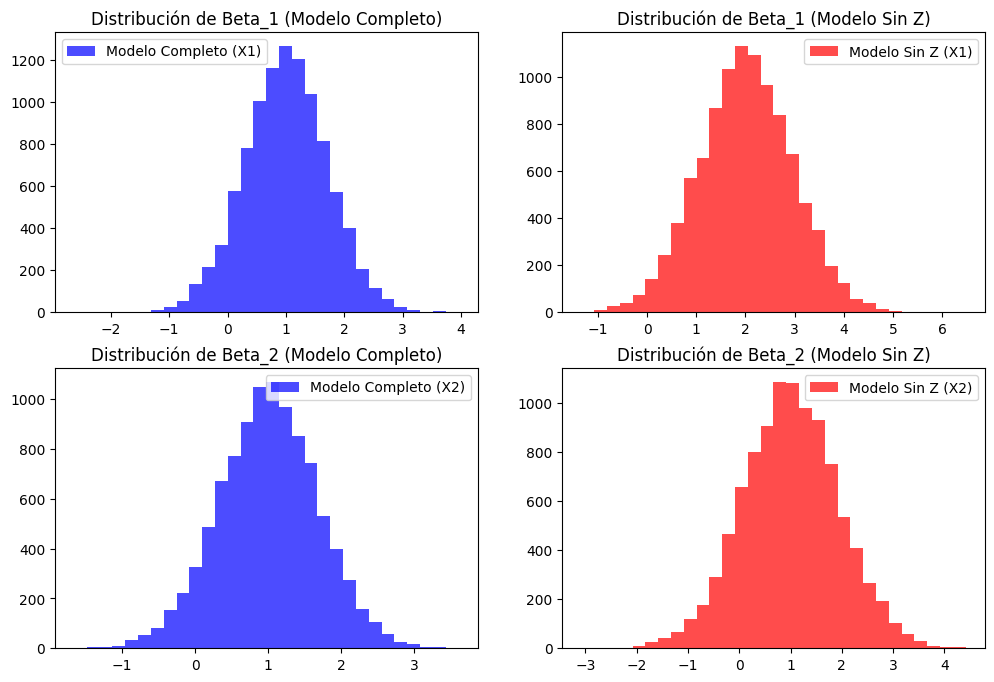

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].hist(coef_completo[:, 0], bins=30, alpha=0.7, color='b', label='Modelo Completo (X1)')
axs[0, 0].set_title("Distribución de Beta_1 (Modelo Completo)")
axs[0, 0].legend()

axs[0, 1].hist(coef_omitido[:, 0], bins=30, alpha=0.7, color='r', label='Modelo Sin Z (X1)')
axs[0, 1].set_title("Distribución de Beta_1 (Modelo Sin Z)")
axs[0, 1].legend()

axs[1, 0].hist(coef_completo[:, 1], bins=30, alpha=0.7, color='b', label='Modelo Completo (X2)')
axs[1, 0].set_title("Distribución de Beta_2 (Modelo Completo)")
axs[1, 0].legend()

axs[1, 1].hist(coef_omitido[:, 1], bins=30, alpha=0.7, color='r', label='Modelo Sin Z (X2)')
axs[1, 1].set_title("Distribución de Beta_2 (Modelo Sin Z)")
axs[1, 1].legend()

plt.show()